In [1]:
import geopandas as gpd
import os
import glob
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import math
import seaborn as sns
from osgeo import gdal
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.regression.linear_model import OLS
from statsmodels.iolib.summary2 import summary_col
import matplotlib.dates as md
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec
from scipy.stats import ttest_ind

def rearrange_plotvals(in_plots,year):
    plots = in_plots.copy()
    plots['Drought degree'] = plots['C9']
    plots.drop(plots.loc[plots[f'?INC{year}'] == 'NIL'].index, inplace=True)
    plots[f'change{year}'] = plots[f'?INC{year}'].astype(float)

    plots[f'bin{year}'],bins = pd.qcut(plots[f'change{year}'],q=5,retbins=True,labels=False)
    bin_labels = [str(np.round(bins[0],1)) + ' to ' + str(np.round(bins[1],1)),
        str(np.round(bins[1],1)) + ' to ' + str(np.round(bins[2],1)),
        str(np.round(bins[2],1)) + ' to ' + str(np.round(bins[3],1)),
        str(np.round(bins[3],1)) + ' to ' + str(np.round(bins[4],1)),
        str(np.round(bins[4],1)) + ' to ' + str(np.round(bins[5],1))]

    plots[f'bin{year}'],bins = pd.qcut(plots[f'change{year}'],q=5,retbins=True,labels=bin_labels)
    
    return plots

def flatten(xss):
    return [x for xs in xss for x in xs]

def arrange_dt(dt_str):
    return dt_str[0:4]+'-'+dt_str[4:6]+'-'+dt_str[6:]
    
def obs_plot(obs_df, out_file):
    ax = obs_df.plot()
    ax.set_ylabel('Num. drought observations')
    ax.set_xlabel('Upper threshold (%)')
    plt.savefig(out_file)
    
def rework_riceplots(rice_plots):
    rice_plots = rice_plots.set_crs('4326')
    rice_plots['area'] = rice_plots.to_crs('3857').geometry.area / 10000

    rice_plots['2019 t/h'] = rice_plots['2019 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2020 t/h'] = rice_plots['2020 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2021 t/h'] = rice_plots['2021 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2022 t/h'] = rice_plots['2022 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2023 t/h'] = rice_plots['2023 M/T'].astype('float32') / rice_plots['area']
    rice_plots['2024 t/h'] = rice_plots['2024 M/T'].astype('float32') / rice_plots['area']
    
    rice_plots['change2024'] = rice_plots['2024 t/h'].astype('float32') - rice_plots['2023 t/h'].astype('float32')
    rice_plots['change2023'] = rice_plots['2023 t/h'].astype('float32') - rice_plots['2022 t/h'].astype('float32')
    rice_plots['change2022'] = rice_plots['2022 t/h'].astype('float32') - rice_plots['2021 t/h'].astype('float32')
    rice_plots['change2021'] = rice_plots['2021 t/h'].astype('float32') - rice_plots['2020 t/h'].astype('float32')
    rice_plots['change2020'] = rice_plots['2020 t/h'].astype('float32') - rice_plots['2019 t/h'].astype('float32')

    return rice_plots

def gen_pca_comp(in_vars,num):
    PCA_input = in_vars
    X_std = StandardScaler().fit_transform(PCA_input)
    pca = PCA(n_components=PCA_input.shape[1])
    principalComponents = pca.fit_transform(X_std)# Plot the explained variances
    features = range(pca.n_components_)
    PCA_components = pd.DataFrame(principalComponents)
    return PCA_components[[col for col in range(num)]]

def extract_indices_year(spindices_year,rice_plots,VICI_folder,SM_folder):
    remove_ids = []
    id_month_dict = {}
    VICI_df = pd.DataFrame(columns = ['id','dt','VICI'])
    SM_df = pd.DataFrame(columns = ['id','dt','SM'])
    
    for i,row in rice_plots.iterrows():
        cent = row.geometry.centroid
    
        #set start and end months
        start_m = row['RCvty1TRP'].split('/')[0]
        end_m = row['RCvty1HVT'].split('/')[-1]
    
        #remove invalid data points
        if (start_m == 'NIL') or (end_m == 'NIL'):
            remove_ids.append(row['id'])
            continue
        if row[f'{year} M/T'] == 'NIL':
            remove_ids.append(row['id'])
            continue
        if row[f'?INC{year}'] == 'NIL':
            remove_ids.append(row['id'])
            continue
    
        
        season_months = [months_dict[start_m], months_dict[end_m]]
        season_months = [f'{i:02}' for i in range(int(season_months[0]),int(season_months[1])+1)]
        id_month_dict[row['id']] = season_months
        subset_VICI = flatten([sorted(glob.glob(os.path.join(VICI_folder,f'VICI-{year}-{month}*.tif'))) for month in season_months])
        
        for dek in subset_VICI:
            
            with rasterio.open(dek) as src:
                val = [x for x in src.sample([(cent.x,cent.y)])][0][0]
            VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
            
        subset_SM = flatten(sorted([glob.glob(os.path.join(SM_folder,f'*{year}{month}*.tif')) for month in season_months]))
        
        for dek in subset_SM:
            
            with rasterio.open(dek) as src:
                val = int([x for x in src.sample([(cent.x,cent.y)])][0][0])
            SM_df = pd.concat([SM_df,pd.DataFrame({'id':[row.id],'dt':[arrange_dt(dek.split('/')[-1][12:20])],'SM':[val]})])
            
    SM_df = SM_df.astype({'SM':'int16'})
    spindices_year = spindices_year[spindices_year['id'].isin(list(set(range(rice_plots['id'].min(),rice_plots['id'].max()+1)) & set(id_month_dict.keys())))]
    spindices_year = spindices_year[spindices_year.apply(lambda x: x['dt'][5:7] in id_month_dict[x['id']], axis=1)]
    spindices_year = spindices_year.merge(VICI_df, on=['id', 'dt'])
    spindices_year = spindices_year.merge(SM_df, on=['id', 'dt'])
    subset = extract_stat_subset(spindices_year)
    return subset

def extract_stat_subset(spindices_year):
    subset_max = spindices_year.drop(columns='dt').groupby('id').max()
    subset_max.rename(columns={col:col+'_max' for col in subset_max.columns},inplace=True)
    subset_median = spindices_year.drop(columns='dt').groupby('id').median()
    subset_median.rename(columns={col:col+'_median' for col in subset_median.columns},inplace=True)
    subset_min = spindices_year.drop(columns='dt').groupby('id').min()
    subset_min.rename(columns={col:col+'_min' for col in subset_min.columns},inplace=True)
    subset_std = spindices_year.drop(columns='dt').groupby('id').std()
    subset_std.rename(columns={col:col+'_std' for col in subset_std.columns},inplace=True)
    subset_count = spindices_year.drop(columns='dt').groupby('id').count()
    subset_countnz = spindices_year.fillna(0).drop(columns='dt').groupby('id').agg(lambda x: x.ne(0).sum())
    subset_countnz = subset_countnz.drop(columns=[col for col in subset_countnz.columns if 'VICI' not in col])
    subset_countnz.rename(columns={'VICI':'VICI_count'},inplace=True)
    subset = pd.concat([subset_max,subset_median,subset_min,subset_std,subset_countnz],axis=1)
    return subset


def merge_plots_indices(rice_plots,subset,year):
    yield_field = f'change{year}'
    merged = rice_plots[['id',yield_field] + list(rice_plots.columns[48:])].merge(subset,left_on='id',right_on='id')
    
    merged['yield'] = merged[yield_field].astype('float32')
    initial_len = len(merged)
    iqr = rice_plots[yield_field].quantile(0.75) - rice_plots[yield_field].quantile(0.25)
    #merged = merged[merged['yield'] < merged['yield'].quantile(0.9)]
    """if year == 2020:
        merged.drop([122,123], inplace=True)
    if year == 2021:
        merged.drop([56], inplace=True)
    if year == 2022:
        merged.drop([38,136], inplace=True)"""
    
    merged.dropna(subset='yield',inplace=True)
    merged = merged[merged['yield'] != 0]
    print(f'{initial_len - len(merged)} removed')
    return merged

def sample_raster_at_points(gdf, raster_path, band=1):
    """
    Sample raster values at point locations in a GeoDataFrame.
    
    Parameters:
    -----------
    gdf : GeoDataFrame
        GeoDataFrame with geometry column containing Point objects
    raster_path : str
        Path to the raster file
    band : int
        Band number to sample (default=1)
    
    Returns:
    --------
    np.array
        Array of sampled values at each point
    """

    with rasterio.open(raster_path) as src:
        # Convert points to coordinate tuples (lon, lat)
        coords = [(geom.x, geom.y) for geom in gdf.geometry.centroid]
        
        # Sample the raster
        sampled_values = list(src.sample(coords, indexes=band))
        date = raster_path.split('_')[3]
        date = date[:4] +'-'+date[4:6]+'-'+date[6:8]
        
    return date, np.nanmean(sampled_values), np.std(sampled_values)

def create_drought_dekads(drought_months,year):
    drought_dekads = []
    for i in range(len(drought_months)):
        for day in ['01','11','21']:
            drought_dekads.append(f'{year}-{drought_months[i]}-{day}')
    return drought_dekads

def get_xlims(data,type):
    fig, ax = plt.subplots(1,3,figsize=(15, 15))
    if type == 'plot':
        ax[0].plot(data.values,md.date2num(data.index.values))
        xlims = ax[0].get_xlim()
        plt.close()
        return xlims
        
    elif type == 'barh1':
        ax[2].barh(md.date2num(data.date.values),data.num)
        xlims = ax[2].get_xlim()
        plt.close()
        return xlims
        
    elif type == 'barh2':
        VICI_mean, SWIA_mean = data
        ax[1].barh(md.date2num(VICI_mean.dek.values)+2,VICI_mean['VICI'])
        ax[1].barh(md.date2num(SWIA_mean.dek.values)-2,SWIA_mean['SWIA'])
        xlims = ax[1].get_xlim()
        plt.close()
        return xlims

def create_rect(transplant_dates, harvest_dates, pan_list, flo_list, x_lims, i, labels):
    
    rect_t = Rectangle((x_lims[0],md.date2num(transplant_dates)[i]),
                       x_lims[1] - x_lims[0],
                       pan_list[i] - md.date2num(transplant_dates)[i],
                       color='green',label="Tillering" if labels and (i==0) else '_nolabel_',alpha=0.3)
    rect_p = Rectangle((x_lims[0],pan_list[i]),
                       x_lims[1] - x_lims[0],
                       flo_list[i] - pan_list[i],
                       color='grey',label="Panicle Initiation" if labels and (i==0) else '_nolabel_',alpha=0.3)
    rect_f = Rectangle((x_lims[0],flo_list[i]),
                       x_lims[1] - x_lims[0],
                       md.date2num(harvest_dates)[i] - flo_list[i],
                       color='orange',label="Flowering" if labels and (i==0) else '_nolabel_',alpha=0.3)
    return rect_t, rect_p, rect_f

In [2]:
months_dict = {'MAR':'03',
               'APR':'04',
               'MAY':'05',
               'JUN':'06',
               'JUL':'07',
               'SEP':'09',
               'AUG':'08',
               'OCT':'10',
               'NOV':'11',
               'DEC':'12',
               'NIL':'NIL'
              }
rice_plots = gpd.read_file(r'/home/eoafrica/shared/MOFODRONI/shapefiles/field_data/RICE_PLOTS_POLYGONS_RF1_fix.shp')
years = [2020,2021,2022,2023,2024]
out_images = r'/home/eoafrica/shared/MOFODRONI/Output_noharmonics/images'

main_dir = Path(os.getcwd()).parent

nigeria_shp = os.path.join(main_dir, 'shapefiles','nigeria_country.shp')
nigeria_vector = gpd.read_file(nigeria_shp)['geometry']

#BoundingBox - Set values to the desired bbox
minX = 2.6 #2.6
maxX = 14.5 #14.5
minY = 4.2 #4.2
maxY = 13.8 #13.8
bbox = [minX,minY,maxX,maxY]


print('Imported plots.')

Imported plots.


In [3]:
spindices = pd.read_csv('/home/eoafrica/shared/MOFODRONI/shapefiles/rice_plots_spi_spei_data.csv')
spindices.drop(columns = spindices.columns[list(spindices.columns).index('id')+1:],inplace=True)
spindices['dt'] = spindices.apply(lambda x: x['time'].split(' ')[0],axis=1)
spindices.drop(columns = ['time','lat','lon'], inplace=True)
spindices

,SPI1,SPI3,SPI6,SPI12,SPEI1,SPEI3,SPEI6,SPEI12,id,dt
0,1.027099,0.056946,0.087901,-0.002508,-0.191424,-0.634704,-0.194509,-0.164145,1,2019-01-01
1,0.808257,1.176137,0.171108,-0.144622,0.405572,-0.097230,-0.138605,-0.233685,1,2019-02-01
2,0.104497,0.996210,-0.155045,-0.153543,0.034702,-0.110778,-0.317002,-0.259087,1,2019-03-01
3,-0.036030,0.150887,0.101817,0.406846,-0.337975,-0.147432,-0.537673,-0.161210,1,2019-04-01
4,0.639820,0.391918,0.519334,0.081584,0.439826,0.147796,0.036488,-0.156625,1,2019-05-01
...,...,...,...,...,...,...,...,...,...,...
12007,-0.062991,-1.153082,-0.832747,-1.989984,-0.287823,-1.225119,-1.801807,-2.762321,154,2025-02-01
12008,-0.587100,-1.021326,-1.471735,-2.066887,-0.990565,-1.082422,-2.349755,-2.701838,154,2025-03-01
12009,-1.812792,-2.296960,-3.289314,-1.913895,-1.990102,-1.833986,-3.372695,-2.247484,154,2025-04-01
12010,-1.312470,-2.572029,-8.222082,-1.901776,-1.367563,-2.776681,-4.696004,-2.007537,154,2025-05-01


### Zonal Analysis

In [130]:
cube_file = r'/home/eoafrica/shared/MOFODRONI/Output/stacks/cube_to_cluster_withsoil.img'
harmonics_file = r'/home/eoafrica/shared/MOFODRONI/Output_new/stacks/harmonics_cube.tif'
wc = rasterio.open(r'/home/eoafrica/shared/MOFODRONI/Output_new/landcover/cropland/WorldCover_merged.tif').read(1)

dataset = gdal.Open(cube_file)
metadata = dataset.GetMetadata()

harmonics_cube = rasterio.open(harmonics_file).read()
harmonics_cube[np.where(harmonics_cube==0)]=np.nan
for band in range(harmonics_cube.shape[0]):
    harmonics_cube[band,:,:] = np.interp(harmonics_cube[band], (np.nanmin(harmonics_cube[band]), np.nanmax(harmonics_cube[band])), (-1, +1))
harmonics_cube = np.nan_to_num(harmonics_cube, nan=0)
harmonics_transposed = np.transpose(harmonics_cube,(1,2,0))
bands = []
for i in range(dataset.RasterCount):
    band = dataset.GetRasterBand(i + 1)
    bands.append(band.ReadAsArray())
bands_2d = np.dstack(bands)
bands_combined = np.concatenate((bands_2d, harmonics_transposed), axis=2) 


In [131]:
bands_2d.shape

(1068, 1325, 186)

In [132]:
bands_2 = bands_combined.copy()
data_wc = bands_2[wc!=2]
data_df = pd.DataFrame(data_wc)
data_df.fillna(-9999)
data_df = data_df.loc[(data_df!=-9999).all(axis=1)]
cut_nodata = np.where(data_df==-9999,0,data_df)

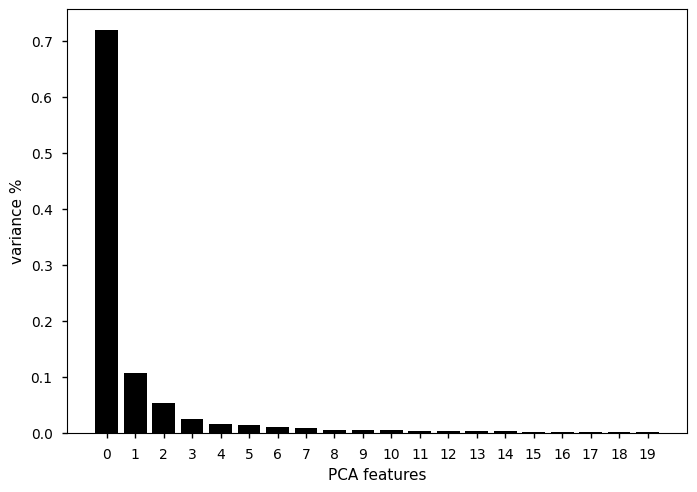

In [135]:
### PCA 
batch_size=10000
X_std = StandardScaler().fit_transform(cut_nodata)
pca = PCA(n_components=20)
principalComponents = pca.fit_transform(X_std)# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)# Save components to a DataFrame
PCA_components = pd.DataFrame(principalComponents)

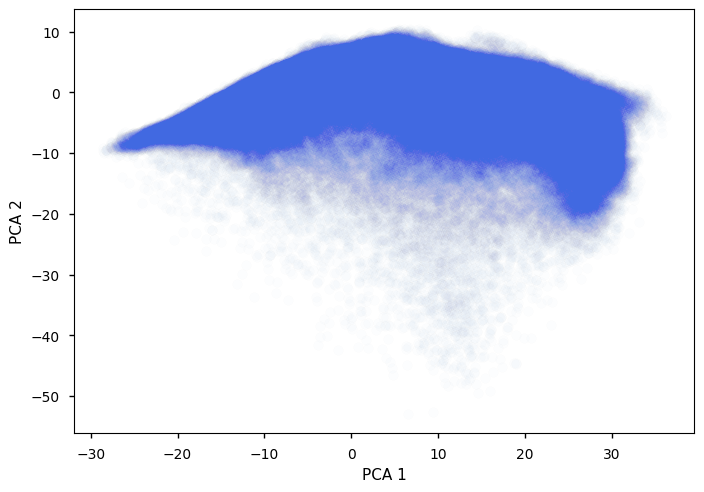

In [136]:
plt.scatter(PCA_components[0], PCA_components[1], alpha=.01, color='royalblue')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.savefig(r'/home/eoafrica/shared/MOFODRONI/images/PCA.jpg')

In [137]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_samples, silhouette_score

ks = range(2, 100)
inertias = []
sil=[]
X = PCA_components.iloc[:,:4]
X_sample = X.sample(10000).reset_index(drop=True)
for k in ks:
    # Create a KMeans instance with k clusters: model
    if k%10 == 0:
        print(k)
    model = MiniBatchKMeans(n_clusters=k, batch_size=batch_size, max_iter=1000, max_no_improvement=100, random_state=42, reassignment_ratio=0)
    
    # Fit model to samples
    model.fit(X)
    cluster_labels = model.fit_predict(X_sample)
    silhouette_avg = silhouette_score(X_sample, cluster_labels)
    # Append the inertia to the list of inertias
    inertias.append(model.inertia_)
    sil.append(silhouette_avg)


10
20
30
40
50
60
70
80
90


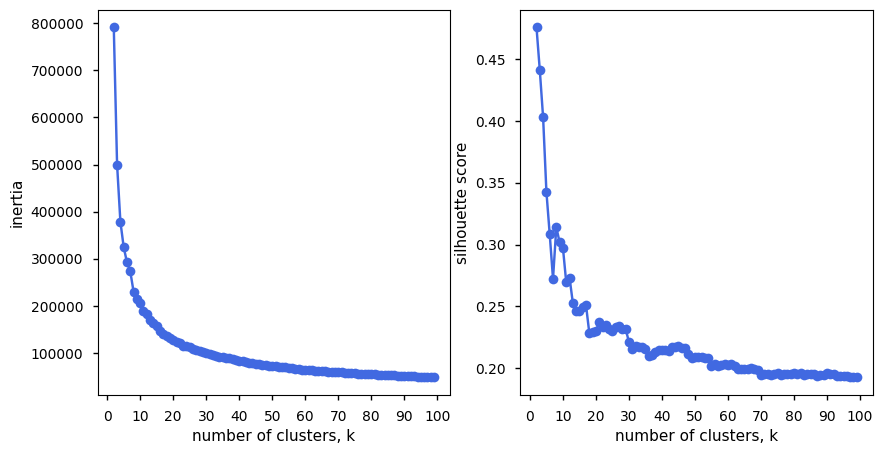

In [138]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].plot(ks, inertias, '-o', color='royalblue')
ax[0].set_xlabel('number of clusters, k')
ax[0].set_ylabel('inertia')
ax[0].set_xticks(range(0,110,10))
ax[1].plot(ks, sil, '-o', color='royalblue')
ax[1].set_xlabel('number of clusters, k')
ax[1].set_ylabel('silhouette score')
ax[1].set_xticks(range(0,110,10))
#plt.savefig(r'/home/eoafrica/shared/MOFODRONI/images/inertia_silhouette.jpg')
plt.show()

### VICI vs SPI/SPEI

In [ ]:
for year in years:

    plots = rearrange_plotvals(rice_plots, year)
    
    analysis_folders = sorted(glob.glob(os.path.join('/home/eoafrica/shared/MOFODRONI/Output_noharmonics/analysis/','*')))
    for analysis_folder in analysis_folders:
        y_loc = analysis_folders.index(analysis_folder)
        fig, axes = plt.subplots(5,8,figsize=(20,20))
        zones_folders = sorted(glob.glob(os.path.join(analysis_folder,'*','VICI')))[1:]
        
        for VICI_test_folder in zones_folders:
            x_loc = zones_folders.index(VICI_test_folder)
            n_zones = VICI_test_folder.split('/')[-2]
            for i, row in plots.iterrows():

                if row[f'YREXP_{str(year)[2:]}'] == None:
                    continue
                drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
                drought_months = [months_dict[m] for m in drought_months]
                subset_dekads = flatten([sorted(glob.glob(os.path.join(VICI_test_folder,f'VICI-{year}-{month}*.tif'))) for month in drought_months])
                sp_dekads = [d.split('-')[1]+ '-' + d.split('-')[2] + '-' + d.split('-')[3].split('.')[0] for d in subset_dekads]
                subset_indices = spindices[spindices['dt'].isin(sp_dekads)]
                subset_indices = subset_indices[subset_indices['id'] == row['id']]
                vici_list = []
                for dek in subset_dekads:
                    with rasterio.open(dek)as src:
                        val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            
                    if math.isnan(val):
                        continue
                        
                    vici_list.append(val)
            
                vals_dict = {'id':[row['id']],
                         subset_indices.columns[0]:[subset_indices[subset_indices.columns[0]].mean()],
                         subset_indices.columns[1]:[subset_indices[subset_indices.columns[1]].mean()],
                         subset_indices.columns[2]:[subset_indices[subset_indices.columns[2]].mean()],
                         subset_indices.columns[3]:[subset_indices[subset_indices.columns[3]].mean()],
                         subset_indices.columns[4]:[subset_indices[subset_indices.columns[4]].mean()],
                         subset_indices.columns[5]:[subset_indices[subset_indices.columns[5]].mean()],
                         subset_indices.columns[6]:[subset_indices[subset_indices.columns[6]].mean()],
                         subset_indices.columns[7]:[subset_indices[subset_indices.columns[7]].mean()],
                         'VICI':[np.mean(vici_list)]}
                if i == 0:
                    vals_pd = pd.DataFrame.from_dict(vals_dict)
                elif i >= 0:
                    vals_pd = pd.concat([vals_pd,pd.DataFrame.from_dict(vals_dict)])
            vals_pd = vals_pd[vals_pd['VICI'] < 100]
            vals_plot = vals_pd[vals_pd.VICI > 0]

            indices = vals_plot.columns[1:-1]

            for ind in indices:
                axes[x_loc,0].set_ylabel(f'VICI {n_zones}')
                axes[x_loc,list(indices).index(ind)].scatter(x=vals_plot[ind],y=vals_plot['VICI'])
                axes[x_loc,list(indices).index(ind)].set_xlabel(ind)
        indices_image_folder = os.path.join(out_images,'SPI_SPEI')
        os.makedirs(indices_image_folder,exist_ok=True)
        plt.savefig(os.path.join(out_images,indices_image_folder,f'VICI_vs_SPI_SPEI_upperthresh{analysis_folder.split('_')[-1]}_{year}.png'))

    
        

In [92]:
plots_chart

,Drought degree,VICI,id,SOILtype,date
0,Moderate Drought,96.774193,82,Loamy,2020-03-11
0,Moderate Drought,80.645164,82,Loamy,2020-03-21
0,Moderate Drought,3.125000,82,Loamy,2020-04-01
0,Moderate Drought,19.354837,82,Loamy,2020-04-11
0,Moderate Drought,60.000004,82,Loamy,2020-04-21
...,...,...,...,...,...
3,Extreme Drought,43.333332,118,Clay,2020-04-21
3,Extreme Drought,43.333332,118,Clay,2020-05-01
3,Extreme Drought,10.000000,118,Clay,2020-05-11
4,"Abnormally Dry,Moderate Drought",3.333333,149,Loamy,2020-05-21


### Annual Boxplots

<Axes: xlabel='VICI', ylabel='Drought degree'>

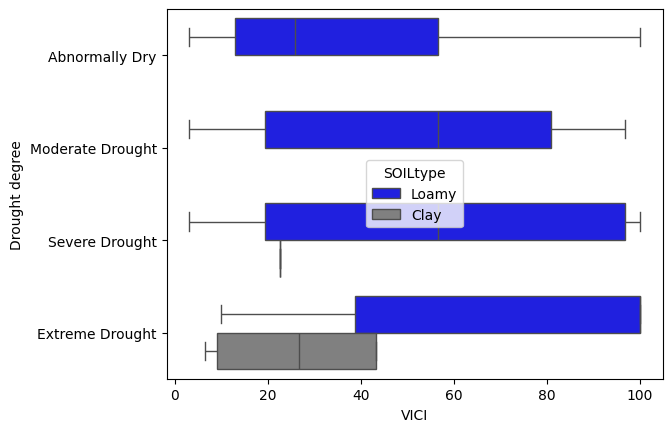

In [91]:
fig, axes = plt.subplots(1,1)
sns.boxplot(ax = axes,data=plots_chart.reset_index(drop=True),x='VICI',y=analysis_column,
                 hue='SOILtype',palette = {"Clay":"grey","Loamy":"blue","Sandy":"orange"},orient='h',order=orders)

In [ ]:
process_zones = [5,30,50]
out_images = '/home/eoafrica/shared/MOFODRONI/Output/images/dm'
approach = 'dm' #'sm'
store_barchart = pd.DataFrame()
years= [2024]
for year in years:
    plots = rearrange_plotvals(rice_plots, year)
    
    fig, axes = plt.subplots(8,len(process_zones),figsize=(20,20))
    zones_folders = [os.path.join(r'/home/eoafrica/shared/MOFODRONI/Output/analysis/',f'{z:02d}zones') for z in process_zones]


    analysis_column = 'Drought degree'# f'bin{year}' 
    
    obs_df = pd.DataFrame(np.nan,index=['p'+str(v) for v in range(15,55,5)],columns=[z.split('/')[-1] for z in zones_folders])
    for zone_folder in zones_folders:
        print(f'running {zone_folder} for {year}')
        analysis_folders = sorted(glob.glob(os.path.join(zone_folder,'*','VICI')))

        x_loc = zones_folders.index(zone_folder)
        n_zones = zone_folder.split('/')[-1]
        for VICI_test_folder in analysis_folders:

            y_loc = analysis_folders.index(VICI_test_folder)
            
            VICI_vals = {}
            for i, row in plots.iterrows():
                # drought months approach
                if approach == 'dm':
                    if row[f'YREXP_{str(year)[2:]}'] == None:
                        continue
                    drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
                    drought_months = [months_dict[m] for m in drought_months]
                    subset_dekads = flatten([sorted(glob.glob(os.path.join(VICI_test_folder,f'VICI-{year}-{month}*.tif'))) for month in drought_months])
                
                elif approach == 'sm':
                    start_m = row['RCvty1TRP'].split('/')[0]
                    end_m = row['RCvty1HVT'].split('/')

                    if len(end_m) > 1:
                        end_m = end_m[1]
                    if len(end_m) == 1:
                        end_m = end_m[0]
                    if (start_m == 'NIL') or (end_m == 'NIL'):
                        continue
                    season_months = [months_dict[start_m], months_dict[end_m]]
                    season_months = [f'{i:02}' for i in range(int(season_months[0]),int(season_months[1])+1)]
                    subset_dekads = flatten([sorted(glob.glob(os.path.join(VICI_test_folder,f'VICI-{year}-{month}*.tif'))) for month in season_months])
                
                for dek in subset_dekads:
                    with rasterio.open(dek)as src:
                        val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
                    #print(f'{dek}: {val}')
                    if math.isnan(val):
                        continue
                    if row[analysis_column] not in VICI_vals.keys():
                        VICI_vals[row[analysis_column]] = [[row['id'],row['SOILtype'],val,dek.split('/')[-1][5:-4]]]
                    else:
                        VICI_vals[row[analysis_column]].append([row['id'],row['SOILtype'],val,dek.split('/')[-1][5:-4]])
        
            plots_chart = pd.DataFrame(VICI_vals.items(),columns=[analysis_column,'VICI'])
            plots_chart = plots_chart.explode('VICI')
            plots_chart[['id','SOILtype','VICI','date']] = pd.DataFrame(plots_chart.VICI.to_list(),index=plots_chart.index)
            plots_chart = plots_chart.loc[plots_chart['VICI']>0]
            if len(plots_chart) > 0:
                store_barchart = pd.concat([store_barchart,pd.DataFrame({
                    'year':year,
                    'zones':n_zones,
                    'p_val':analysis_folder.split('analysis_')[-1],
                    'non-zero':[len(plots_chart[plots_chart['VICI']>0])/len(plots_chart)],
                    'zero':[len(plots_chart[plots_chart['VICI']==0])/len(plots_chart)]
                })])
            else:
                store_barchart = pd.concat([store_barchart,pd.DataFrame({
                    'year':year,
                    'zones':n_zones,
                    'p_val':analysis_folder.split('analysis_')[-1],
                    'non-zero':[len(plots_chart)],
                    'zero':[len(plots_chart)]
                })])

            obs_df.iloc[y_loc,x_loc] = len(plots_chart[plots_chart['VICI']>0])
            
            if 'bin' in analysis_column:
                img_folder = 'boxplots_YieldBins'
                orders = list(plots_chart[analysis_column].unique())
                orders.sort(key = lambda x: float(x.split(' ')[0]))
            elif 'Drought' in analysis_column:
                img_folder = 'boxplots_DroughtDegree'
                orders = ['Abnormally Dry','Moderate Drought','Severe Drought', 'Extreme Drought']

            sns.boxplot(ax = axes[y_loc, x_loc],data=plots_chart.reset_index(drop=True),x='VICI',y=analysis_column,
                        hue='SOILtype',palette = {"Clay":"grey","Loamy":"blue","Sandy":"orange"},orient='h',order=orders)
            if not axes[y_loc][x_loc].get_legend() is None:
                axes[y_loc][x_loc].get_legend().set_visible(False)
                if x_loc == 0:
                    axes[y_loc][x_loc].set_ylabel(f'Drought degree p{VICI_test_folder.split('_')[-1].split('/')[0]}')
                if x_loc > 0:
                    axes[y_loc][x_loc].set_ylabel('')
                    axes[y_loc][x_loc].set_yticks('')
                if y_loc < 7:
                    axes[y_loc][x_loc].set_xlabel('')
                if y_loc == 7:
                    axes[y_loc][x_loc].set_xlabel(f'VICI {n_zones}')
                    
    fig.tight_layout()
    print(f'Saving to: {os.path.join(out_images,img_folder)}')
    os.makedirs(os.path.join(out_images,img_folder), exist_ok = True)
    plt.savefig(os.path.join(out_images,img_folder,f'upperthresh_vs_zones_DroughtDegree_{year}.png'))

    obs_plot(obs_df,os.path.join(out_images,img_folder,f'upperthresh_vs_zones_lineplot_{year}.png'))
    

running /home/eoafrica/shared/MOFODRONI/Output/analysis/05zones for 2023
running /home/eoafrica/shared/MOFODRONI/Output/analysis/30zones for 2023
running /home/eoafrica/shared/MOFODRONI/Output/analysis/50zones for 2023
Saving to: /home/eoafrica/shared/MOFODRONI/Output/images/dm/boxplots_DroughtDegree
running /home/eoafrica/shared/MOFODRONI/Output/analysis/05zones for 2024


### Point-level Timeseries

In [4]:
spindices = pd.read_csv('/home/eoafrica/shared/MOFODRONI/shapefiles/rice_plots_spi_spei_data.csv')
spindices['year'] = spindices.apply(lambda x: x['time'][:4],axis=1)
spindices['date'] = spindices.apply(lambda x: x['time'][:10],axis=1)
spindices.date

0        2019-01-01
1        2019-02-01
2        2019-03-01
3        2019-04-01
4        2019-05-01
            ...    
12007    2025-02-01
12008    2025-03-01
12009    2025-04-01
12010    2025-05-01
12011    2025-06-01
Name: date, Length: 12012, dtype: object

In [5]:
years_list = ['2020','2021','2022','2023','2024']
VICI_path = r'/home/eoafrica/shared/MOFODRONI/Output/analysis/100zones/analysis_05_30/VICI'
SWIA_path = r'/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/100zones/analysis_05_30/SWIA'
VICI_files = sorted([file for file in glob.glob(os.path.join(VICI_path,'*')) if file[-14:-10] in years_list])
SWIA_files = sorted([file for file in glob.glob(os.path.join(SWIA_path,'*')) if file[-14:-10] in years_list])
plots = rice_plots.copy()

for year in years_list:
    plots = plots.drop(plots.loc[plots[f'?INC{year}'] == 'NIL'].index)

states = plots.STATE.unique()

state = states[0]
print(state)
plots_state = plots[plots['STATE']==state]
plots_state = plots_state[plots_state[f'YREXP_{str(year)[2:]}'].notnull()]
    
state_ids = list(plots_state.id)
filter_year = spindices[spindices.year.isin(years_list)]
filter_state = filter_year[filter_year.id.isin(state_ids)]
year_dates = filter_state.date.unique()
    
df_filtered = filter_state[[col for col in filter_state.columns if any(x in col for x in ['SPI', 'SPEI', 'date'])]]
spi_spei_cols = [col for col in df_filtered.columns if 'date' not in col]
grouped = df_filtered.groupby('date')[spi_spei_cols].agg(['mean', 'std'])
    
print(len(plots_state))

NIGER
46


In [6]:
min_drought = ''
drought_df = pd.DataFrame()
for year in years_list:
    year_calc_df = pd.DataFrame()
    for i, row in plots_state.iterrows():
        if row[f'YREXP_{str(year)[2:]}'] is None:
            continue
        drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
        
        drought_months = [months_dict[m] for m in drought_months]
        drought_dekads = create_drought_dekads(drought_months,year)

        year_calc_df = pd.concat([year_calc_df,
                                pd.DataFrame({d:[1] for d in drought_dekads})])
        
    drought_df = pd.concat([drought_df,
                            pd.DataFrame(year_calc_df.sum()).reset_index().rename(columns={'index':'date',0:'num'}).sort_values(by='date').reset_index(drop=True)])


In [27]:
VICI_pos = pd.DataFrame()
SWIA_pos = pd.DataFrame()
for i, row in plots_state.reset_index(drop=True).iterrows():
    
    tp = months_dict[row['RCvty1TRP'].split('/')[0]]
    ht = months_dict[row['RCvty1HVT'].split('/')[-1]]
    if i == 0:
        prev_tp = tp
        prev_ht = ht
    else:
        if int(tp) < int(prev_tp):
            prev_tp = tp
        if int(ht) > int(prev_ht):
            prev_ht = ht
            
    for dek in VICI_files:
        with rasterio.open(dek)as src:
            val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            if val > 0:
                VICI_pos = pd.concat([VICI_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
    for dek in SWIA_files:
        with rasterio.open(dek)as src:
            val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            if val > 0:
                SWIA_pos = pd.concat([SWIA_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
    print(tp, ht)
    break

VICI_mean = VICI_pos.groupby('dek').mean().reset_index()
SWIA_mean = SWIA_pos.groupby('dek').mean().reset_index()

#mean_tp = months_dict[plots_state['RCvty1TRP'].unique()[0]]
mean_ht = months_dict[plots_state['RCvty1HVT'].unique()[0]]

transplant_dates = [f'{y}-{prev_tp}-01' for y in years_list]
harvest_dates = [f'{y}-{mean_ht}-01' for y in years_list]
harvest_dates

06 10


['2020-10-01', '2021-10-01', '2022-10-01', '2023-10-01', '2024-10-01']

In [65]:
plots_season = plots.copy()
plots_season['s_len'] = md.date2num(plots_season['RCvty1HVT'].apply(lambda x: f'2024-{months_dict[x.split('/')[0]]}-01')) - md.date2num(plots_season['RCvty1TRP'].apply(lambda x: f'2024-{months_dict[x.split('/')[0]]}-01'))
plots_season.loc[146]

id                                                          153
FARMER'S N                                       NWORIE MERCY\n
PHONE                                             08025644417\n
STATE                                                    EBONYI
LGA                                                        IKWO
SOILtype                                                  Loamy
SWAMPLd                                         Lowland-Wetland
RICEvarty                                                FARO44
RICEvarty2                                               FARO45
RCvty1TRP                                                   JUN
RCvty2TRP                                                   JUN
RCvty1HVT                                                   NOV
RCvty2HVT                                                   NOV
DRTpst5y                         Experienced Drought past 5 yrs
YREXP_20                                                   None
YREXP_21                                

In [ ]:
VICI_pos = pd.DataFrame()
SWIA_pos = pd.DataFrame()
for i, row in plots_state.reset_index(drop=True).iterrows():
    
    tp = months_dict[row['RCvty1TRP'].split('/')[0]]
    ht = months_dict[row['RCvty1HVT'].split('/')[-1]]
    if i == 0:
        prev_tp = tp
        prev_ht = ht
    else:
        if int(tp) < int(prev_tp):
            prev_tp = tp
        if int(ht) > int(prev_ht):
            prev_ht = ht
            
    for dek in VICI_files:
        with rasterio.open(dek)as src:
            val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            if val > 0:
                VICI_pos = pd.concat([VICI_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
    for dek in SWIA_files:
        with rasterio.open(dek)as src:
            val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            if val > 0:
                SWIA_pos = pd.concat([SWIA_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'SWIA':[val]})])
    print(tp, ht)
    break

VICI_mean = VICI_pos.groupby('dek').mean().reset_index()
SWIA_mean = SWIA_pos.groupby('dek').mean().reset_index()

#mean_tp = months_dict[plots_state['RCvty1TRP'].unique()[0]]
mean_ht = months_dict[plots_state['RCvty1HVT'].unique()[0]]

transplant_dates = [f'{y}-{prev_tp}-01' for y in years_list]
harvest_dates = [f'{y}-{mean_ht}-01' for y in years_list]
harvest_dates

In [8]:
pan_dict = {}
flo_dict = {}
month_pos = pd.DataFrame()
for y in years_list:
    pan_stage = pd.DataFrame()
    flo_stage = pd.DataFrame()
    for i, row in plots_state.iterrows():
        tp = months_dict[row['RCvty1TRP'].split('/')[0]]
        ht = months_dict[row['RCvty1HVT'].split('/')[-1]]
        pan_stage = pd.concat([pan_stage,pd.DataFrame({'dek':
                                                       md.date2num([create_drought_dekads([tp],y)[0]])+50})])
        flo_stage = pd.concat([flo_stage,pd.DataFrame({'dek':
                                                       md.date2num([create_drought_dekads([tp],y)[0]])+80})])
        
        for i in range(int(tp),int(ht)):
            temp_m = pd.DataFrame({'year':y,'dek':create_drought_dekads([f'{i:02d}'],y)})
            month_pos = pd.concat([month_pos,temp_m])
    
    pan_dict[y] = pan_stage['dek'].value_counts().index.tolist()[0]
    flo_dict[y] = flo_stage['dek'].value_counts().index.tolist()[0]

    

In [ ]:
fig = plt.figure(figsize=(15,15))
gs = gridspec.GridSpec(5, 4)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec = gs[:,:3])
gs2 = gridspec.GridSpecFromSubplotSpec(15, 2, subplot_spec = gs[:,3],height_ratios=[0.025,0.15,0.025]*5,width_ratios=[0.02,0.98])#,hspace=1.5)
ax = [fig.add_subplot(cell) for cell in gs1]
ax2 = [fig.add_subplot(cell) for cell in gs2]
i=3
i_list = []
plot_cols = ['SPI3','SPEI3']

for y in years_list:
    yield_all = plots_state[[f'{y} t/h' for y in years_list]]
    for z in years_list:
        yield_all[f'{z} t/h'] = yield_all[f'{z} t/h'][yield_all[f'{z} t/h'].lt(yield_all[f'{z} t/h'].quantile(0.85))]

    yield_all = yield_all.stack().groupby(level=0).mean().to_frame().rename(columns={0:'mean yield'})
    yield_state = plots_state[f'{y} t/h'][plots_state[f'{y} t/h'].lt(plots_state[f'{y} t/h'].quantile(0.85))]
    if y == '2024':
        yield_change = plots_state[f'change{y}'][plots_state[f'change{y}'].between(plots_state[f'change{y}'].quantile(0.05),plots_state[f'change{y}'].quantile(0.95))]
    else:
        yield_change = plots_state[f'change{y}'][plots_state[f'change{y}'].between(plots_state[f'change{y}'].quantile(0.05),plots_state[f'change{y}'].quantile(0.95))]
    ttest_stat = ttest_ind(yield_state, yield_all['mean yield'],equal_var=False)
    print(y,ttest_stat)
    ax2[i].boxplot([yield_state,yield_all['mean yield'],yield_change],tick_labels=[f'{y} \nyield','mean \nyield','yield \nchange'])
    ax2[i].spines["left"].set_visible(False)
    ax2[i].spines["bottom"].set_visible(False)
    ax2[i].spines["top"].set_visible(False)
    ax2[i].yaxis.tick_right()
    ax2[i].yaxis.set_label_position("right")
    ax2[i].set_ylabel('yield (t/h)')
    ax2[i].set_ylim(np.round(np.min([0,yield_change.min()])-1),
                             np.round(np.max([yield_state.max(),yield_all['mean yield'].max()])+1))
    
    if ttest_stat.pvalue < 0.05:
        ax2[i].text(0.95,yield_state.max()+1,'a')
        ax2[i].text(1.95,yield_all['mean yield'].max()+1,'b')
    else:
        ax2[i].text(0.95,yield_state.max()+1,'a')
        ax2[i].text(1.95,yield_all['mean yield'].max()+1,'a')
    i_list.append(i)
    i+=6
    
for n in [n for n in range(30) if n not in i_list ]:
    ax2[n].axis('off')
ax_lims = md.date2num(grouped[plot_cols[0]]['mean'].index.values)

### Plot graph 1
x_lims = get_xlims(grouped['SPI3']['mean'],'plot')
for i in range(len(transplant_dates)):
    rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels=False)
    ax[0].add_patch(rect_t)
    ax[0].add_patch(rect_p)
    ax[0].add_patch(rect_f)
    
ax[0].plot([0]* len(grouped['SPI3']['mean'].values),md.date2num(grouped['SPI3'].index.values),color='grey',linestyle='--',alpha=0.5)

for col in plot_cols:
    mean = grouped[col]['mean']
    std = grouped[col]['std']
    
    # Plot line for mean
    ax[0].plot(mean.values, md.date2num(mean.index.values), label=col)
    
ax[0].set_ylabel('Date')
ax[0].set_xlabel('mean SPI/SPEI value')

### Plot graph 2

x_lims = get_xlims([VICI_mean,SWIA_mean],'barh2')
for i in range(len(transplant_dates)):
    rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels = False)
    ax[1].add_patch(rect_t)
    ax[1].add_patch(rect_p)
    ax[1].add_patch(rect_f)
    
ax[1].barh(md.date2num(VICI_mean.dek.values)+2,VICI_mean['VICI'],height=11,label='mean NDVIA',color='red', alpha=0.5)
ax[1].barh(md.date2num(SWIA_mean.dek.values)-2,SWIA_mean['SWIA'],height=11,label='mean SWIA', color='green', alpha=0.5)
ax[1].tick_params(axis="y", which='major', length=0, labelleft=False, labelright=False)
ax[1].tick_params(axis="y", which='minor', length=0, labelleft=False, labelright=False)
ax[1].set_xlabel('mean NDVIA/SWIA value')

### Plot graph 3
x_lims = get_xlims(drought_df,'barh1')
for i in range(len(transplant_dates)):
    rect_t, rect_p, rect_f = create_rect(transplant_dates, harvest_dates, list(pan_dict.values()), list(flo_dict.values()), x_lims, i, labels = True)
    ax[2].add_patch(rect_t)
    ax[2].add_patch(rect_p)
    ax[2].add_patch(rect_f)
    
ax[2].barh(md.date2num(drought_df.date.values),drought_df.num,height=11,label='num droughts', color='blue', alpha = 0.5)
ax[2].tick_params(axis="y", which='major', length=0, labelleft=False, labelright=True)
ax[2].tick_params(axis="y", which='minor', length=0, labelleft=False, labelright=True)
ax[2].set_xlabel('number of reported drought dekads')

for idx, a in enumerate(ax):
    for tick in a.yaxis.get_major_ticks():
        tick.set_pad(7 * tick.get_pad())
    a.yaxis.set_major_locator(md.YearLocator())
    a.yaxis.set_major_formatter(md.DateFormatter("%Y"))
    a.tick_params(which='major', axis='x', pad=20)
    a.yaxis.set_minor_locator(md.MonthLocator(interval=2))
    a.yaxis.set_minor_formatter(md.DateFormatter("%b"))
    a.set_ylim(ax_lims[-1],ax_lims[0])
    a.spines["top"].set_visible(False)
    
    if idx == 0:
        a.spines["right"].set_visible(False)
    if idx == 1:
        a.spines["left"].set_visible(False)
        a.spines["right"].set_visible(False)
    if idx == 2:
        a.spines["left"].set_visible(False)
    
fig.legend(loc='upper center',ncols=10)
plt.savefig(os.path.join(r'/home/eoafrica/shared/MOFODRONI/Output/images/final_imgs',f'100z30t_{state}_fullgraph.svg'),format='svg',dpi=1200)
#plt.tight_layout()

##### ignore

In [ ]:
state_ids = list(plots_state.id)

filter_year = spindices[spindices.year.isin(years_list)]
filter_state = filter_year[filter_year.id.isin(state_ids)]

year_dates = filter_state.date.unique()
filter_drought = filter_state[~filter_state[f'YREXP_{str(year)[2:]}'].isnull()]
df_filtered = filter_drought[[col for col in filter_drought.columns if any(x in col for x in ['SPI', 'SPEI', 'date'])]]
spi_spei_cols = [col for col in df_filtered.columns if 'date' not in col]
grouped = df_filtered.groupby('date')[spi_spei_cols].agg(['mean', 'std'])


drought_df = pd.DataFrame()
for i, row in plots_state.iterrows():
    drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
    drought_months = [months_dict[m] for m in drought_months]
    drought_dekads = create_drought_dekads(drought_months,year)
    drought_df = pd.concat([drought_df,
                            pd.DataFrame({d:[1] for d in drought_dekads})])
    
drought_df = pd.DataFrame(drought_df.sum()).reset_index().rename(columns={'index':'date',0:'num'}).sort_values(by='date')

In [ ]:
fig,ax = plt.subplots(figsize=(20,4))
i=0
for y in years_list:
    sns.kdeplot(md.date2num(month_pos[month_pos['year']==y]['dek']),alpha=0.3,ax=ax,color='green')
    kde_line = ax.lines[i]
    x_data = kde_line.get_xdata()
    y_data = kde_line.get_ydata()
    mask_t = x_data <= pan_dict[y]
    mask_p = (x_data > pan_dict[y]) & (x_data < flo_dict[y])
    mask_f = x_data >= flo_dict[y]
    ax.fill_between(x_data, y_data, where=mask_t, alpha=0.6, color="green", 
                label="Tillering" if i == 0 else '_nolabel_')
    ax.fill_between(x_data, y_data, where=mask_p, alpha=0.6, color="grey", 
                label="Panicle Initiation" if i == 0 else '_nolabel_')
    ax.fill_between(x_data, y_data, where=mask_f, alpha=0.6, color="orange", 
                label="Flowering" if i == 0 else '_nolabel_')
    print(x_data[0])
    
    
    i+=1

ax.xaxis.set_major_locator(md.YearLocator())
ax.xaxis.set_major_formatter(md.DateFormatter("%Y"))

ax.xaxis.set_minor_locator(md.MonthLocator(interval=2))
ax.xaxis.set_minor_formatter(md.DateFormatter("%b"))
plt.legend(loc='upper right')

## horizontal
"""for y in years_list:
    sns.kdeplot(y=md.date2num(month_pos[month_pos['year']==y]['dek']),alpha=0.3,ax=ax[2],color='green')
    kde_line = ax[2].lines[i]
    x_data = kde_line.get_xdata()
    y_data = kde_line.get_ydata()
    mask_t = y_data <= pan_dict[y]
    mask_p = (y_data > pan_dict[y]) & (y_data < flo_dict[y])
    mask_f = y_data >= flo_dict[y]
    ax[2].fill_betweenx(y_data, x_data, where=mask_t, alpha=0.6, color="green", 
                label="Tillering" if i == 0 else '_nolabel_')
    ax[2].fill_betweenx(y_data, x_data, where=mask_p, alpha=0.6, color="grey", 
                label="Panicle Initiation" if i == 0 else '_nolabel_')
    ax[2].fill_betweenx(y_data, x_data, where=mask_f, alpha=0.6, color="orange", 
                label="Flowering" if i == 0 else '_nolabel_')
    
    i+=1
ax2 = ax[2].twiny()"""



#### Points original

In [5]:
VICI_path = r'/home/eoafrica/shared/MOFODRONI/Output/analysis/100zones/analysis_05_50/VICI'
files_SM_path = sorted(glob.glob(os.path.join(r'/home/eoafrica/shared/MOFODRONI/SM/','*.tif')))

years = [2022]
for year in years:
    year = str(year)
    
    VICI_files = sorted([file for file in glob.glob(os.path.join(VICI_path,'*')) if year in file])
    files_SM = [file for file in files_SM_path if file.split('_')[3][:4]==year]
    plots = rearrange_plotvals(rice_plots, year)
    
    #fig,ax = plt.subplots(figsize=(15,15))
    
    for state in plots.STATE.unique():
        plots_state = plots[plots['STATE']==state]
        plots_state = plots_state[plots_state[f'YREXP_{str(year)[2:]}'].notnull()]

        SM_df = pd.DataFrame(columns=['date','SM_mean','SM_std'])
        
        for file in files_SM:
            SM_vals = sample_raster_at_points(plots_state, file)
            SM_df = pd.concat([SM_df,pd.DataFrame({'date':[SM_vals[0]],
                                                   'SM_mean':[SM_vals[1]],
                                                   'SM_std':[SM_vals[2]]})])
        break

        

In [6]:
state_ids = list(plots_state.id)

filter_year = spindices[spindices.year==year]
filter_state = filter_year[filter_year.id.isin(state_ids)]

year_dates = filter_state.date.unique()
filter_drought = filter_state[~filter_state[f'YREXP_{str(year)[2:]}'].isnull()]
df_filtered = filter_drought[[col for col in filter_drought.columns if any(x in col for x in ['SPI', 'SPEI', 'date'])]]
spi_spei_cols = [col for col in df_filtered.columns if 'date' not in col]
grouped = df_filtered.groupby('date')[spi_spei_cols].agg(['mean', 'std'])


drought_df = pd.DataFrame()
for i, row in plots_state.iterrows():
    drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
    drought_months = [months_dict[m] for m in drought_months]
    drought_dekads = create_drought_dekads(drought_months,year)
    drought_df = pd.concat([drought_df,
                            pd.DataFrame({d:[1] for d in drought_dekads})])
    
drought_df = pd.DataFrame(drought_df.sum()).reset_index().rename(columns={'index':'date',0:'num'}).sort_values(by='date')

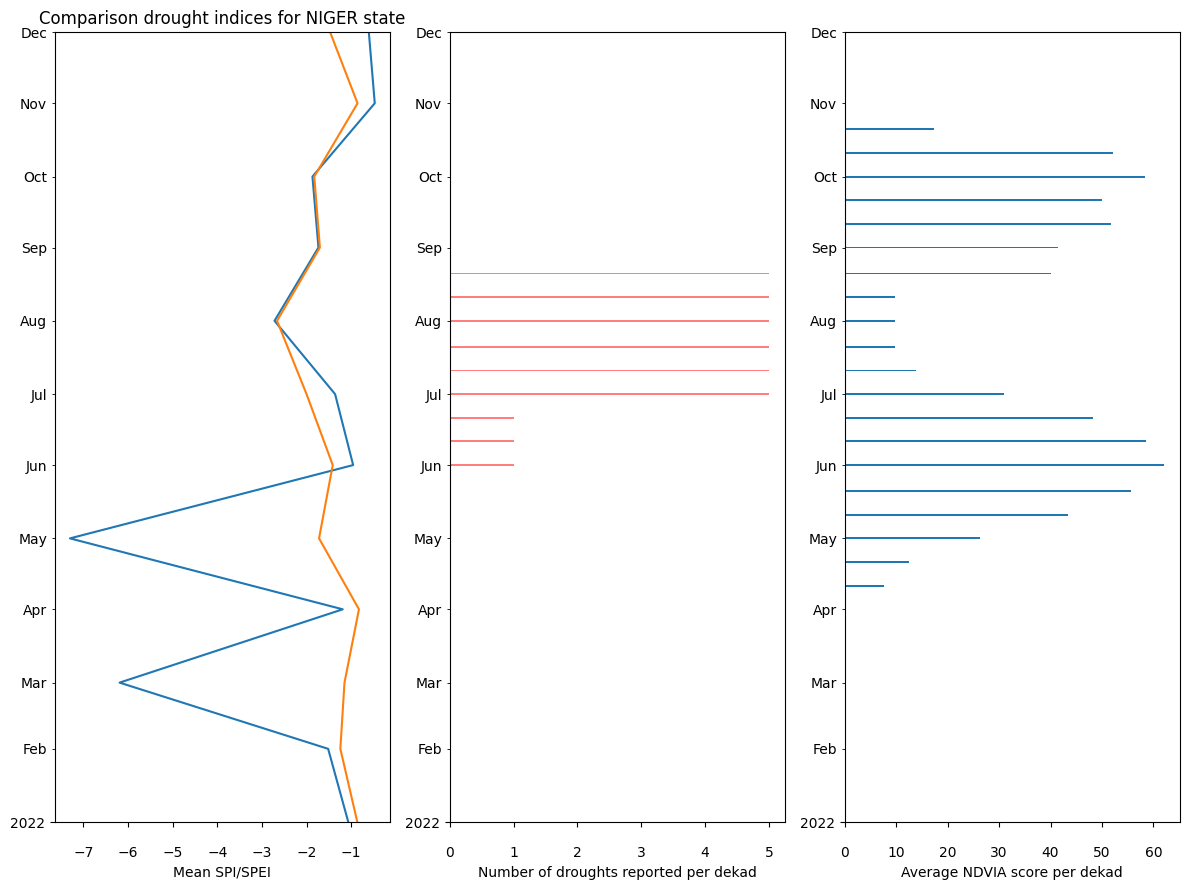

In [47]:
years_fmt = md.DateFormatter("%Y")
month_fmt = md.DateFormatter("%b")
fig, ax = plt.subplots(1,3,figsize=(12, 9))
plot_cols = ['SPI3','SPEI3']
years = md.YearLocator()
# Plot each SPI/SPEI column
ax_lims = md.date2num(grouped[plot_cols[0]]['mean'].index.values)
for col in plot_cols:
    mean = grouped[col]['mean']
    std = grouped[col]['std']
    
    # Plot line for mean
    ax[0].plot(mean.values, md.date2num(mean.index.values), label=col)
    
    # Add shaded error region for std
    """ax[0].fill_between(md.date2num(mean.index),
                       mean.values - std.values,
                       mean.values + std.values, 
                       alpha=0.2)"""

ax[1].barh(md.date2num(drought_df.date.values),drought_df.num.values,color='red',alpha=0.5, label='Number of farmer drought dekads')
ax[2].barh(md.date2num(VICI_mean.dek.values),VICI_mean.VICI.values,label='NDVIA')
for idx, a in enumerate(ax):
    a.yaxis.set_major_locator(md.YearLocator())
    a.yaxis.set_major_formatter(years_fmt)
    a.tick_params(which='major', axis='x', pad=14)
    a.yaxis.set_minor_locator(md.MonthLocator())
    a.yaxis.set_minor_formatter(month_fmt)
    a.set_ylim(ax_lims[0],ax_lims[-1])


ax[0].set_xlabel('Date')
ax[0].set_xlabel('Mean SPI/SPEI')
ax[1].set_xlabel('Number of droughts reported per dekad')
ax[2].set_xlabel('Average NDVIA score per dekad')
ax[0].set_title(f'Comparison drought indices for {state} state')

plt.tight_layout()
plt.show()

In [10]:
VICI_files = sorted([file for file in glob.glob(os.path.join(VICI_path,'*')) if year in file])
VICI_pos = pd.DataFrame()
for i, row in plots_state.iterrows():

    for dek in VICI_files:
        with rasterio.open(dek)as src:
            val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
            if val > 0:
                VICI_pos = pd.concat([VICI_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'VICI':[val]})])


In [11]:
VICI_counts = pd.DataFrame(pd.DataFrame(VICI_pos.dek).sort_values(by='dek').value_counts()).reset_index().rename(columns={'count':'num')
VICI_counts

SyntaxError: closing parenthesis ')' does not match opening parenthesis '{' (3866193375.py, line 1)

In [12]:
VICI_mean = VICI_pos.groupby('dek').mean().reset_index()

In [13]:
VICI_path = r'/home/eoafrica/shared/MOFODRONI/Output_new/analysis/analysis_05_50/060zones/VICI'
files_SM_path = sorted(glob.glob(os.path.join(r'/home/eoafrica/shared/MOFODRONI/SM/','*.tif')))


for year in years:
    year = str(year)
    
    
    files_SM = [file for file in files_SM_path if file.split('_')[3][:4]==year]
    plots = rearrange_plotvals(rice_plots, year)
    
    fig,ax = plt.subplots(3,3,figsize=(15,15))
    counter_x = 0
    counter_y = 0
    for state in plots.STATE.unique():
        plots_state = plots[plots['STATE']==state]
        plots_state = plots_state[plots_state[f'YREXP_{str(year)[2:]}'].notnull()]
                
        print(f'{len(plots_state)} obs for {state} in {year}')
        out_state_ts = os.path.join(out_images,'point_timeseries_perstate_SM',state,year)
        if not os.path.exists(out_state_ts):
            os.makedirs(out_state_ts)
            
        for i, row in plots_state.iterrows():
            dates_dict = {}
            row_id = row.id
            # add SM observation
            plot_centroid = rice_plots[rice_plots.id==row_id].geometry.centroid
            for file in files_SM:
                with rasterio.open(file) as src:
                    val = [x for x in src.sample([(plot_centroid.x,plot_centroid.y)])][0][0]
                date = file.split('_')[3]
                date = date[:4] +'-'+date[4:6]+'-'+date[6:8]
                dates_dict[date] = val
            sm_df = pd.DataFrame(list(dates_dict.items()),columns = ['date','SWI'])
            
            VICI_pos = pd.DataFrame()
            if counter_x == 0 and counter_y == 0:
                first_point = row_id
            point = spindices[spindices['id']==row_id]
            point_year = point[point['year']==year]
            point_year.loc[:,'time'] = point_year.apply(lambda x: x['time'][:10],axis=1)
            
            ax[counter_y][counter_x].plot(pd.to_datetime(point_year.time),point_year.SPEI3,color='royalblue',label='SPEI3')
            ax[counter_y][counter_x].plot(pd.to_datetime(point_year.time),point_year.SPI3,color='orange',label='SPI3')
            ax_twin = ax[counter_y][counter_x].twinx()
            ax_twin.plot(pd.to_datetime(sm_df.date),sm_df.SWI,color='green',label='SWI')
            h,l = ax[counter_y][counter_x].get_legend_handles_labels()
            
            ax[counter_y][counter_x].tick_params(axis='x', labelrotation=45)
            ax[counter_y][counter_x].set_xlabel('Date')
            ax[counter_y][counter_x].set_ylabel('SPI/SPEI value')
            ax[counter_y][counter_x].set_title(f'Point id: {row_id}')
            
            if row[f'YREXP_{str(year)[2:]}'] != None:
                drought_months = row[f'YREXP_{str(year)[2:]}'].split('/')
                drought_months = [months_dict[m] for m in drought_months]
    
                drought_limits = create_drought_limits(year,drought_months)
                s_drought = mdates.date2num(drought_limits['start_drought'][0])
                e_drought = mdates.date2num(drought_limits['end_drought'][0])
                width = e_drought - s_drought
                y_lims = ax[counter_y][counter_x].get_ylim()
                rect = Rectangle((s_drought, y_lims[0]), width, abs(y_lims[0]) + y_lims[1], color='red',alpha=0.5)
                print(counter_y, counter_x, drought_limits)
                for dek in VICI_files:
                    with rasterio.open(dek)as src:
                        val = [x for x in src.sample([(row.geometry.centroid.x,row.geometry.centroid.y)])][0][0]
                        if val > 0:
                            VICI_pos = pd.concat([VICI_pos,pd.DataFrame({'dek':[dek.split('/')[-1][5:-4]],'VICI':[val]})])
                if len(VICI_pos) > 0:
                    for date in pd.to_datetime(VICI_pos.dek):
                        ax[counter_y][counter_x].axvline(date,label='positive VICI')
                ax[counter_y][counter_x].add_patch(rect)
            
            fig.legend(h[:4], l[:4])
            plt.tight_layout()
            
            counter_x += 1
            
            if counter_x == 3:
                counter_y += 1
                counter_x = 0
                
            if counter_y == 3:
                last_point = row_id
                plt.savefig(os.path.join(out_state_ts,f'index_timeseries_points{first_point}-{last_point}_p50_60zones.jpg'))
                plt.clf()
                fig,ax = plt.subplots(3,3,figsize=(15,15))
                counter_y = 0
                counter_x = 0
                
            if i == plots_state.index[-1]:
                last_point = row_id
                plt.savefig(os.path.join(out_state_ts,f'index_timeseries_points{first_point}-{last_point}_p50_60zones.jpg'))

            
        
    

TypeError: 'YearLocator' object is not iterable

### Econometric modelling

In [62]:

SM_folder = r'/home/eoafrica/shared/MOFODRONI/SM'

rice_plots = rework_riceplots(gpd.read_file(r'/home/eoafrica/shared/MOFODRONI/shapefiles/field_data/RICE_PLOTS_POLYGONS_RF1_fix.shp'))
# create dummy variables
rice_plots = pd.merge(rice_plots,pd.get_dummies(rice_plots[['SOILtype','RICEvarty']],dtype=int),left_index=True, right_index=True)

In [63]:
zones = [5,10,20,30,40,50,70]
thresholds = [15,20,25,30,35,40,45,50]
years = [2024]
for zone in zones:
    print(f'Running {zone} zones')
    zone_dict = {'zones':[zone]}
    for u_thresh in thresholds:
        print(f'Running {u_thresh} threshold')
        VICI_folder = f'/home/eoafrica/shared/MOFODRONI/Output/analysis/{zone:02d}zones/analysis_05_{u_thresh}/VICI'
        
        for year in years:
            print(f'Processing {year}')
            subset = extract_indices_year(spindices[spindices['dt'].str.contains(str(year))],
                                                  rice_plots,
                                                  VICI_folder,
                                                  SM_folder)
            merged_year = merge_plots_indices(rice_plots,subset,year)
            if year == years[0]:
                merged = merged_year[merged_year.columns.drop(f'change{year}')]
            if year != years[0]:
                merged = pd.concat([merged,merged_year[merged_year.columns.drop(f'change{year}')]])

        in_cols = [col for col in merged.columns[1:] if 'yield' not in col]
        pred_col = merged['yield']
        simple_reg = OLS(pred_col,merged[in_cols],missing='drop')
        r2_score = simple_reg.fit().rsquared
        zone_dict[u_thresh]=[r2_score]
        print(f'Model for {zone} zones and p{u_thresh} R²: {r2_score}')
        break
    if zone == zones[0]:
        zone_df = pd.DataFrame(zone_dict)
    else:
        zone_df = pd.concat([zone_df,pd.DataFrame(zone_dict)])
    break
       

Running 5 zones
Running 15 threshold
Processing 2024


/tmp/ipykernel_15687/1498642574.py:108: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  VICI_df = pd.concat([VICI_df,pd.DataFrame({'id':[row.id],'dt':[dek.split('/')[-1][5:-4]],'VICI':[val]})])


8 removed
Model for 5 zones and p15 R²: 0.8036436307238226


/tmp/ipykernel_15687/1498642574.py:136: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  subset_countnz = spindices_year.fillna(0).drop(columns='dt').groupby('id').agg(lambda x: x.ne(0).sum())


#### Stepwise


In [321]:
pred_col = merged['yield']
features = merged[in_cols]

import statsmodels as sm

def forward_selection(X, y):
    selected_features = []
    while True:
        remaining_features = [f for f in X.columns if f not in selected_features]
        
        new_pval = pd.Series(index=remaining_features)
        for feature in remaining_features:
            model = OLS(y, sm.tools.tools.add_constant(X[selected_features + [feature]]),missing='drop').fit()
            new_pval[feature] = model.pvalues[feature]
        print(f'Model R²: {model.rsquared}')
        min_pval = new_pval.min()
        if min_pval < 0.1:  # Adjust threshold as needed
            selected_features.append(new_pval.idxmin())
        else:
            break
    return selected_features, model


def backward_elimination(X, y):
    selected_features = list(X.columns)
    while True:
        model = OLS(y, sm.tools.tools.add_constant(X[selected_features]),missing='drop').fit()
        pvalues = model.pvalues.iloc[1:]  # Ignore intercept
        max_pval = pvalues.max()
        print(f'Model R²: {model.rsquared}')
        if max_pval > 0.1:
            excluded_feature = pvalues.idxmax()
            selected_features.remove(excluded_feature)
        else:
            break
    return selected_features, model
    
selected, model = forward_selection(features, pred_col)
print(f"Forward selected features ({len(selected)} total): {selected}")
print(f"R²: {model.rsquared}")
print(f"RMSE: {np.sqrt(model.mse_model)}")

selected, model = backward_elimination(features, pred_col)
print(f"Backward selected features ({len(selected)} total): {selected}")
print(f"R²: {model.rsquared}")
print(f"RMSE: {np.sqrt(model.mse_model)}")


Model R²: 0.009237742119255432
Model R²: 0.1353345587790945
Model R²: 0.19551486892646186
Model R²: 0.22724748857118282
Model R²: 0.2611836440275749
Model R²: 0.2836075072782599
Model R²: 0.32651638612456646
Model R²: 0.35510251054128705
Forward selected features (7 total): ['SPEI1_min', 'SPI1_min', 'SOIL_N', 'SPEI6_max', 'SPEI12_min', 'SPI12_median', 'SPEI1_std']
R²: 0.35510251054128705
RMSE: 4.154381612958739
Model R²: 0.5697652742674686
Model R²: 0.5697051265921482
Model R²: 0.5695113363692987
Model R²: 0.5693836340952263
Model R²: 0.5690980620980093
Model R²: 0.5687426323194338
Model R²: 0.5685986709662552
Model R²: 0.568239150762862
Model R²: 0.5679270498043556
Model R²: 0.5676929090740813
Model R²: 0.5673204121599084
Model R²: 0.5660933215421938
Model R²: 0.5649509213198529
Model R²: 0.561811157172935
Model R²: 0.5578563852582823
Model R²: 0.5548791549319405
Model R²: 0.5514969662854132
Model R²: 0.5475939591710881
Model R²: 0.5455389683479217
Model R²: 0.5356045768406484
Backwar

In [323]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
lasso = Lasso(random_state = 0)
alpha_range = np.logspace(-4, 1, 50)

# Define parameters dictionary
param = {'alpha':[0.0001,0.001,0.01,0.1,1]}

# score base on r2
grid_search_r2 = GridSearchCV(lasso,param_grid=param,scoring='r2',cv=5)
grid_search_r2.fit(features, pred_col)

# score base on MAE
grid_search_MAE = GridSearchCV(lasso,param_grid=param,scoring ='neg_mean_absolute_error',cv=5)
grid_search_MAE.fit(features, pred_col)


# results
print('Scoring R2')
print('Best R2 score   : ', grid_search_r2.best_score_)
print('Best parameters : ', grid_search_r2.best_params_)
print()


# results
print('Scoring MAE')
print('Best MAE score  : ', abs(grid_search_MAE.best_score_))
print('Best parameters : ', grid_search_MAE.best_params_)

# Set up the GridSearchCV object
grid_search = GridSearchCV(estimator=lasso, param_grid=param, cv=5)

# Fit the GridSearchCV object to the training data
grid_search.fit(features, pred_col)

# Print the best alpha value and mean squared error
print("Best alpha value: ", grid_search.best_params_['alpha'])

/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.395e+01, tolerance: 2.924e-02
  model = cd_fast.enet_coordinate_descent(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.851e+01, tolerance: 2.697e-02
  model = cd_fast.enet_coordinate_descent(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Scoring R2
Best R2 score   :  -0.5486265126634302
Best parameters :  {'alpha': 1}

Scoring MAE
Best MAE score  :  1.7500841381019665
Best parameters :  {'alpha': 1}


/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.395e+01, tolerance: 2.924e-02
  model = cd_fast.enet_coordinate_descent(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.851e+01, tolerance: 2.697e-02
  model = cd_fast.enet_coordinate_descent(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or

Best alpha value:  1


In [324]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score

#Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(features)

#Lasso Cross validation
lasso_cv = LassoCV(alphas = alpha_range, random_state=0).fit(X_train, pred_col)

#score
print(lasso_cv.score(X_train, pred_col))

coef = pd.Series(lasso_cv.coef_, index=features.columns)
print("Lasso picked " + str(sum(coef != 0)) + " variables and eliminated the other " +  str(sum(coef == 0)) + " variables")
print("Coefficients:")
print(coef[coef!=0])
print(list(coef[coef!=0].keys()))
model = OLS(pred_col, sm.tools.tools.add_constant(features[list(coef[coef!=0].keys())]),missing='drop').fit()
print(model.rsquared)
print(np.sqrt(model.mse_model))
model.summary()

/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.737e-02, tolerance: 2.924e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.863e-01, tolerance: 2.924e-02
  model = cd_fast.enet_coordinate_descent_gram(
/home/eoafrica/.conda/envs/MOFODRONI/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the f

0.10946951829995955
Lasso picked 2 variables and eliminated the other 41 variables
Coefficients:
SPEI1_min    0.257815
SPI1_std    -0.108928
dtype: float64
['SPEI1_min', 'SPI1_std']
0.16540910575841272
5.67073324935303


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  yield   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.150
Method:                 Least Squares   F-statistic:                     10.90
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           4.80e-05
Time:                        14:08:26   Log-Likelihood:                -219.94
No. Observations:                 113   AIC:                             445.9
Df Residuals:                     110   BIC:                             454.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.8184      0.817      7.119      0.000       4.199       7.438
SPEI1_min      1.0153      0.355      2.862      0.005       0.312       1.718
SPI1_std      -0.4947      0.243     -2.036      0.044      -0.976      -0.013
==============================================================================
Omnibus:                        7.053   Durbin-Watson:                   1.633
Prob(Omnibus):                  0.029   Jarque-Bera (JB):                7.253
Skew:                           0.619   Prob(JB):                       0.0266
Kurtosis:                       2.913   Cond. No.                         18.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from sklearn.linear_model import LassoCV

scale_X = StandardScaler().fit(features).transform(features)
scale_y = StandardScaler().fit(pd.DataFrame(pred_col)).transform(pd.DataFrame(pred_col))
scale_y = scale_y.ravel()  # ravel collapses a (150, 1) vector to (150,)
reg_lasso = LassoCV(cv=10).fit(scale_X, scale_y)


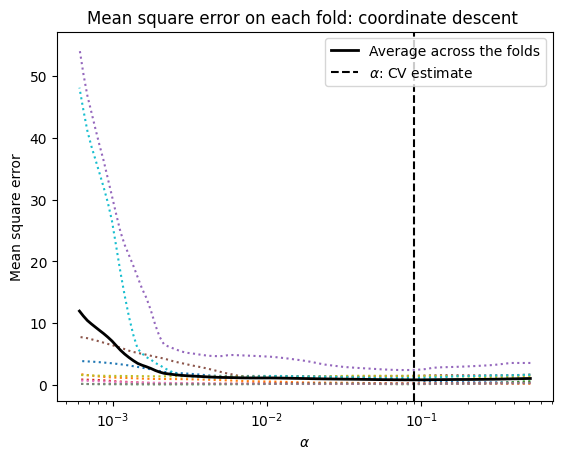

In [39]:
EPSILON = 1e-4  # This is to avoid division by zero while taking the base 10 logarithm
plt.figure()
plt.semilogx(reg_lasso.alphas_ + EPSILON, reg_lasso.mse_path_, ':')
plt.plot(reg_lasso.alphas_ + EPSILON, reg_lasso.mse_path_.mean(axis=-1), 'k',
         label='Average across the folds', linewidth=2)
plt.axvline(reg_lasso.alpha_ + EPSILON, linestyle='--', color='k',
            label=r'$\alpha$: CV estimate')
plt.legend()
plt.xlabel(r'$\alpha$')
plt.ylabel('Mean square error')
plt.title('Mean square error on each fold: coordinate descent ')
plt.axis('tight')
plt.show()

#### OLS

{122: 0.5053966764534349, 245: 0.45362225441647763, 282: 0.3567520130730924, 360: 0.17287012825713302, 38: 0.10383490998277133}
{3: 0.45362225441647763, 41: 0.3567520130730924, 124: 0.17287012825713302, 40: 0.10383490998277133}
Highest likelihood: model52


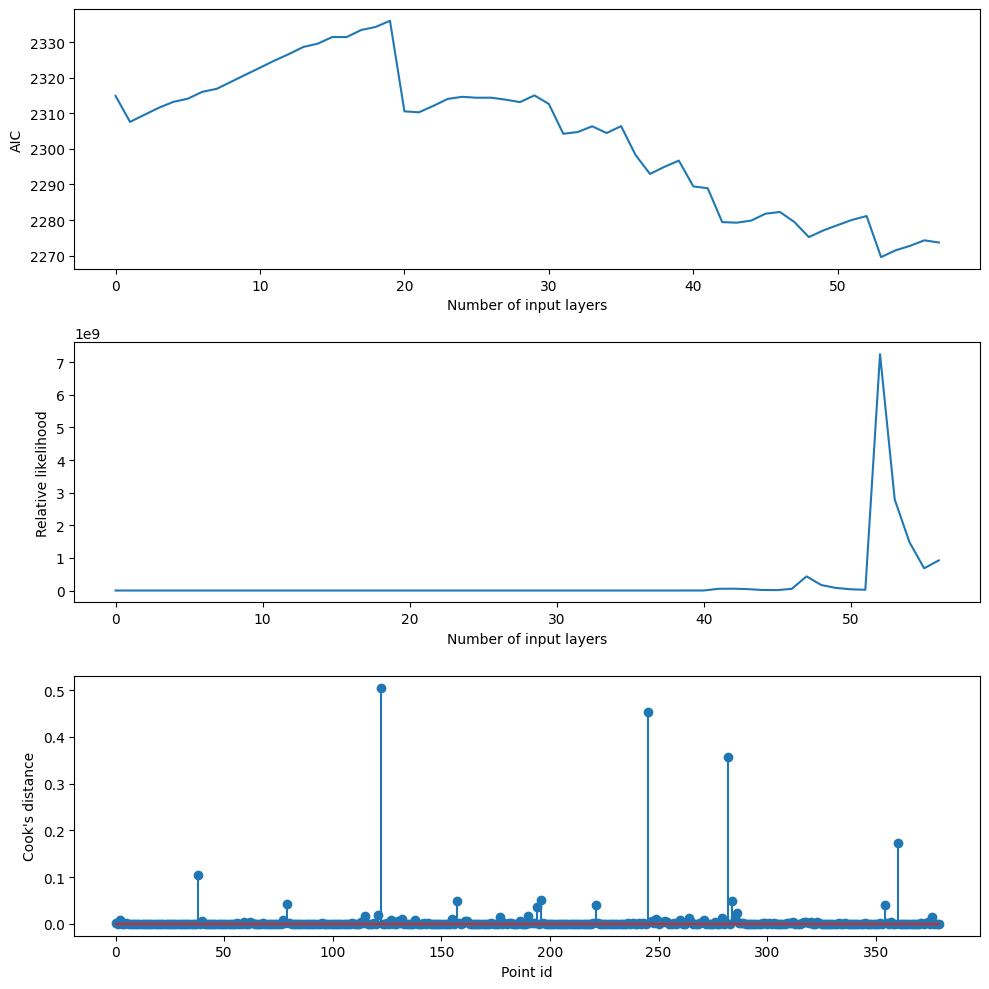

In [138]:

models = {}
results = {}
model_names ={}
in_cols = [col for col in merged.columns[1:] if 'yield' not in col]
pred_col = merged['yield']
col_list = []
aic = []
i=0
for colname in in_cols:
    #print(colname)
    col_list.append(colname)
    #col_list = colname
    #print(f'model{i}')
    #print(col_list)
    model_names[f'model{i}']=col_list
    simple_reg = OLS(pred_col,merged[col_list],missing='drop')
    models[f'model{i}'] = simple_reg
    results[f'model{i}'] = simple_reg.fit()
    aic.append(simple_reg.fit().aic)
    i+=1
    
influence=simple_reg.fit().get_influence()
(cooks,_)=influence.cooks_distance

aic_comp = []
for i in range(len(aic)-1):
    aic_comp.append(np.exp((aic[0] - aic[i+1])/2))

fig,ax = plt.subplots(3,1,figsize=(10,10))
ax[0].plot(range(len(col_list)),aic)
ax[0].set_xlabel('Number of input layers')
ax[0].set_ylabel('AIC')

ax[1].plot(range(len(aic)-1),aic_comp)
ax[1].set_xlabel('Number of input layers')
ax[1].set_ylabel('Relative likelihood')

ax[2].stem(np.arange(len(merged['yield'])),cooks)#
ax[2].set_xlabel('Point id')
ax[2].set_ylabel("Cook's distance")
plt.tight_layout()
top_points = dict(reversed([x for x in sorted(enumerate(cooks), key=lambda x: x[1])[-5:]]))
print(top_points)
top_points = dict(zip([merged.iloc[p].name for p in top_points.keys()],list(top_points.values())))
print(top_points)
print(f'Highest likelihood: model{aic_comp.index(np.max(aic_comp))}')

In [121]:
info_dict={'R-squared' : lambda x: "{:.2f}".format(x.rsquared),
           'No. observations' : lambda x: "{0:d}".format(int(x.nobs))}

results_table = summary_col(results=list(results.values()),
                            float_format='%0.2f',
                            stars = True,
                            model_names=list(results.keys()),
                            info_dict=info_dict,
                            regressor_order=[col for col in merged.columns if 'SP1' in col])
results_table.add_title('Table - OLS Regressions')

#print(results_table)


In [139]:
simple_reg = OLS(merged['yield'],merged[col_list],missing='drop')
simple_reg.fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  yield   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.198
Method:                 Least Squares   F-statistic:                     2.672
Date:                Tue, 03 Mar 2026   Prob (F-statistic):           3.54e-08
Time:                        11:35:53   Log-Likelihood:                -1079.8
No. Observations:                 380   AIC:                             2274.
Df Residuals:                     323   BIC:                             2498.
Df Model:                          56                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
SOILtype_Clay          -3.1466      5.026     -0.626      0.532     -13.034       6.741
SOILtype_Loamy         -3.4188      4.946     -0.691      0.490     -13.150       6.312
SOILtype_NIL           -2.1990      5.936     -0.370      0.711     -13.878       9.480
SOILtype_Sandy         -3.5805      6.191     -0.578      0.563     -15.761       8.600
RICEvarty_AWOLAYE       0.8539      2.151      0.397      0.692      -3.379       5.087
RICEvarty_EBANGICHI     0.6024      1.988      0.303      0.762      -3.308       4.513
RICEvarty_FARO15        0.3341      3.098      0.108      0.914      -5.762       6.430
RICEvarty_FARO44       -0.6438      1.747     -0.369      0.713      -4.081       2.793
RICEvarty_FARO45        1.6069      3.054      0.526      0.599      -4.401       7.614
RICEvarty_FARO52        0.0088      2.698      0.003      0.997      -5.298       5.316
RICEvarty_FARO56       -4.0072      2.993     -1.339      0.182      -9.896       1.882
RICEvarty_FARO57       -2.4774      2.234     -1.109      0.268      -6.873       1.919
RICEvarty_FARO61       -2.4870      3.598     -0.691      0.490      -9.566       4.592
RICEvarty_FARO66        0.0065      4.865      0.001      0.999      -9.564       9.577
RICEvarty_JERUSALEM    -3.9855      3.781     -1.054      0.293     -11.425       3.454
RICEvarty_LAMIYETU      1.0090      2.568      0.393      0.695      -4.044       6.062
RICEvarty_OFADA        -3.1655      1.837     -1.723      0.086      -6.780       0.449
SPI1_max                1.1843      1.064      1.113      0.267      -0.909       3.278
SPI3_max                2.4782      1.795      1.380      0.168      -1.053       6.010
SPI6_max                0.1649      0.797      0.207      0.836      -1.403       1.733
SPI12_max              -0.4459      0.770     -0.580      0.563      -1.960       1.068
SPEI1_max              -1.9624      1.780     -1.102      0.271      -5.465       1.540
SPEI3_max              -2.9916      2.785     -1.074      0.284      -8.471       2.488
SPEI6_max               3.2142      1.314      2.447      0.015       0.630       5.799
SPEI12_max              0.4812      2.318      0.208      0.836      -4.079       5.042
VICI_max               -0.0661      0.073     -0.909      0.364      -0.209       0.077
SM_max                  0.0724      0.065      1.106      0.270      -0.056       0.201
SPI1_median            -0.1462      1.220     -0.120      0.905      -2.546       2.254
SPI3_median             0.0106      1.208      0.009      0.993      -2.365       2.386
SPI6_median             0.5838      0.490      1.192      0.234      -0.379       1.547
SPI12_median           -0.2033      0.396     -0.513      0.608      -0.983       0.577
SPEI1_median           -0.2895      1.659     -0.175      0.862      -3.553       2.974
SPE

In [1147]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = merged[col_list]
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
print(vif_data)

          feature           VIF
0          SOIL_N      2.676691
1          RICE_N     11.342594
2        SPI1_max   2914.906008
3        SPI3_max    897.257161
4        SPI6_max    389.727215
5       SPI12_max   1489.807770
6       SPEI1_max    817.533085
7       SPEI3_max   3130.754314
8       SPEI6_max   1037.968430
9      SPEI12_max   4375.664921
10       VICI_max   1210.590871
11         SM_max  13297.236785
12    SPI1_median   1442.436822
13    SPI3_median    621.426772
14    SPI6_median    552.860857
15   SPI12_median    204.822297
16   SPEI1_median   1237.233127
17   SPEI3_median   2014.309245
18   SPEI6_median   5983.786964
19  SPEI12_median   4214.522584
20    VICI_median    187.953880
21      SM_median   3559.348091
22       SPI1_min   6555.486757
23       SPI3_min   8650.021767
24       SPI6_min   1415.266915
25      SPI12_min   4674.796483
26      SPEI1_min   6232.976984
27      SPEI3_min  13659.938296
28      SPEI6_min  17076.265546
29     SPEI12_min  43618.350455
30      

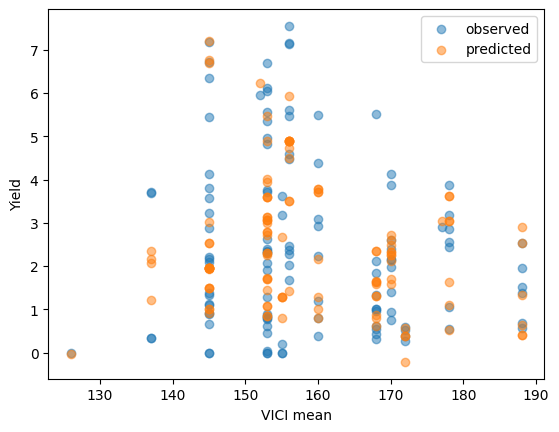

In [1497]:
# Plot predicted values

fig, ax = plt.subplots()

ax.scatter(merged['SM_max'], merged['yield'], alpha=0.5, label='observed')
ax.scatter(merged['SM_max'], simple_reg.fit().predict(), alpha=0.5, label='predicted')
ax.set_xlabel('VICI mean')
ax.set_ylabel('Yield')
ax.legend()


#### PCA

In [450]:
farmer_vars = merged[[col for col in merged.columns if '_N' in col]]
SPI_vars = merged[[col for col in merged.columns if 'SPI' in col]]
SPEI_vars = merged[[col for col in merged.columns if 'SPEI' in col]]
SM_vars = merged[[col for col in merged.columns if 'SM' in col]]
VICI_vars = merged[[col for col in merged.columns if 'VICI' in col]]
yield_var = merged['yield']
SPEI_vars

,SPEI1_max,SPEI3_max,SPEI6_max,SPEI12_max,SPEI1_median,SPEI3_median,SPEI6_median,SPEI12_median,SPEI1_min,SPEI3_min,SPEI6_min,SPEI12_min,SPEI1_std,SPEI3_std,SPEI6_std,SPEI12_std
0,0.486843,-1.408368,-3.472868,-3.811096,-1.004974,-2.854728,-5.462451,-5.369762,-2.775917,-3.928965,-6.068380,-7.151897,1.223633,1.042220,1.039431,1.356000
2,0.486843,-0.877591,-2.575131,-3.811096,-1.318755,-2.293735,-4.976945,-5.299291,-2.926565,-3.928965,-6.068380,-7.151897,1.328149,1.173164,1.364621,1.325033
4,0.486843,-1.408368,-3.472868,-3.811096,-1.004974,-2.854728,-5.462451,-5.369762,-2.775917,-3.928965,-6.068380,-7.151897,1.223633,1.042220,1.039431,1.356000
5,0.486843,-1.408368,-3.472868,-3.811096,-0.747904,-2.293735,-5.538645,-6.045164,-1.632536,-3.928965,-6.068380,-7.151897,0.896047,1.146982,1.150334,1.552528
6,0.486843,-1.408368,-3.472868,-3.811096,-1.004974,-2.854728,-5.462451,-5.369762,-2.775917,-3.928965,-6.068380,-7.151897,1.223633,1.042220,1.039431,1.356000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,0.663819,-0.449821,-1.919592,-1.366023,0.071230,-1.178060,-2.208705,-1.630831,-3.270108,-2.014069,-2.984510,-2.782256,1.848822,0.675987,0.458161,0.638587
142,0.414688,-1.084529,-2.226093,-1.429893,-0.930861,-1.849632,-3.043785,-1.629591,-2.670043,-3.605603,-6.469184,-2.072571,1.442363,1.146162,1.942815,0.288207
143,0.414688,-1.084529,-1.454824,-1.511533,0.028294,-1.314660,-2.274318,-2.215595,-2.670043,-2.358406,-3.601302,-3.122152,1.463008,0.464573,0.763200,0.575334
144,0.414688,-1.084529,-1.454824,-1.511533,0.028294,-1.314660,-2.274318,-2.215595,-2.670043,-2.358406,-3.601302,-3.122152,1.463008,0.464573,0.763200,0.575334


In [451]:
pca_farmer = gen_pca_comp(farmer_vars,2)
pca_SPI = gen_pca_comp(SPI_vars,5)
pca_SPEI = gen_pca_comp(SPEI_vars,4)
pca_SM = gen_pca_comp(SM_vars,2)
pca_VICI = gen_pca_comp(VICI_vars,2)

In [452]:
pca_farmer = pca_farmer.rename(columns={0:'farmer1',1:'farmer2'})
pca_SPI = pca_SPI.rename(columns={0:'SPI1',
                                  1:'SPI2',
                                  2:'SPI3',
                                  3:'SPI4',
                                  4:'SPI5'})
pca_SPEI = pca_SPEI.rename(columns={0:'SPEI1',
                                    1:'SPEI2',
                                    2:'SPEI3',
                                    3:'SPEI4'})
pca_SM = pca_SM.rename(columns={0:'SM1',1:'SM2'})
pca_VICI = pca_VICI.rename(columns={0:'VICI1',1:'VICI2'})

In [453]:
subset = pd.concat([pca_farmer,pca_SPI,pca_SPEI,pca_SM,pca_VICI],axis=1)
subset.index.names = ['id']
subset

,farmer1,farmer2,SPI1,SPI2,SPI3,SPI4,SPI5,SPEI1,SPEI2,SPEI3,SPEI4,SM1,SM2,VICI1,VICI2
id,,,,,,,,,,,,,,,
0,-0.857298,0.327293,-3.447315,0.608763,-2.846352,-1.209501,0.816946,-1.949254,-1.604211,1.451158,1.509599,0.280750,-0.935216,0.721976,-0.750033
1,-0.712269,0.182264,-3.714853,0.474771,-1.119948,-1.351201,-1.035217,-1.588491,-0.588389,0.853744,1.235500,0.329558,-0.990063,0.721976,-0.750033
2,-0.857298,0.327293,-3.447315,0.608763,-2.846352,-1.209501,0.816946,-1.949254,-1.604211,1.451158,1.509599,0.280750,-0.935216,0.721976,-0.750033
3,-0.857298,0.327293,-3.428921,0.747731,-3.331141,-1.180412,0.662153,-1.672566,-1.467107,2.023976,2.209285,1.572881,-1.685583,-0.862754,0.378048
4,-0.857298,0.327293,-3.447315,0.608763,-2.846352,-1.209501,0.816946,-1.949254,-1.604211,1.451158,1.509599,0.280750,-0.935216,0.721976,-0.750033
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
126,-0.857298,0.327293,3.870952,1.749831,2.598974,2.957954,3.369985,2.962952,1.296777,0.491088,-0.866357,3.265540,1.027557,-0.862754,0.378048
127,-0.857298,0.327293,1.041109,0.234473,-0.491812,-1.053088,1.141945,1.376272,0.327260,-1.066572,0.780631,1.557126,1.943351,-0.862754,0.378048
128,-0.857298,0.327293,2.652912,-1.106614,-1.537461,0.084886,0.064259,2.900189,0.389956,0.421836,-0.618667,3.314744,0.983218,-0.862754,0.378048


In [454]:
cols_pca = [['farmer1','farmer2'],
            ['SPI1','SPI2','SPI3','SPI4','SPI5'],
            ['SPEI1','SPEI2','SPEI3','SPEI4'],
            ['SM1','SM2'],
            ['VICI1','VICI2']]
models = {}
results = {}
model_names ={}
col_list = []
aic = []
i=0
for colname in cols_pca:
    col_list+=colname
    model_names[f'model{i}']=col_list
    simple_reg = OLS(list(yield_var),subset[col_list],missing='drop')
    models[f'model{i}'] = simple_reg
    results[f'model{i}'] = simple_reg.fit()
    aic.append(simple_reg.fit().aic)
    i+=1

In [455]:
info_dict={'R-squared' : lambda x: "{:.2f}".format(x.rsquared),
           'No. observations' : lambda x: "{0:d}".format(int(x.nobs))}

results_table = summary_col(results=list(results.values()),
                            float_format='%0.2f',
                            stars = True,
                            model_names=list(results.keys()),
                            info_dict=info_dict,
                            regressor_order=[col for col in merged.columns if 'SP1' in col])
results_table.add_title('Table - OLS Regressions')

print(results_table)

              Table - OLS Regressions
                 model0 model1 model2 model3 model4
---------------------------------------------------
farmer1          0.11   -0.07  -0.05  -0.02  -0.01 
                 (0.16) (0.23) (0.23) (0.24) (0.26)
farmer2          -0.16  -0.05  0.00   -0.04  -0.01 
                 (0.18) (0.23) (0.24) (0.25) (0.26)
SPI1                    0.03   0.02   0.04   0.07  
                        (0.07) (0.30) (0.30) (0.32)
SPI2                    -0.22  -0.44  -0.38  -0.26 
                        (0.13) (0.33) (0.36) (0.49)
SPI3                    -0.14  0.16   0.21   0.16  
                        (0.12) (0.24) (0.26) (0.30)
SPI4                    -0.00  0.01   0.01   0.03  
                        (0.13) (0.17) (0.17) (0.18)
SPI5                    0.13   0.11   0.05   -0.04 
                        (0.15) (0.19) (0.23) (0.33)
SPEI1                          0.02   0.00   0.00  
                               (0.24) (0.25) (0.26)
SPEI2                     

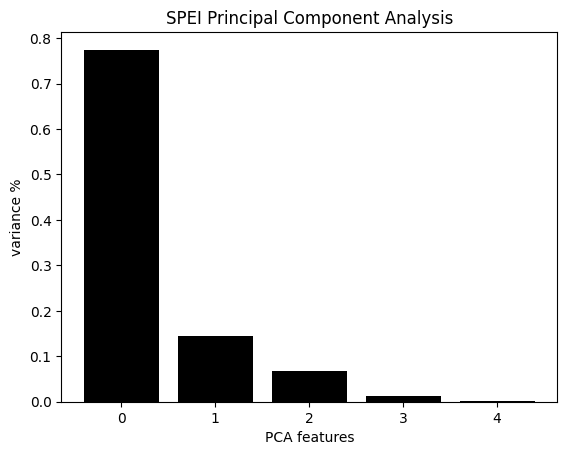

In [428]:
PCA_input = VICI_vars
X_std = StandardScaler().fit_transform(PCA_input)
pca = PCA(n_components=PCA_input.shape[1])
principalComponents = pca.fit_transform(X_std)# Plot the explained variances
features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.title('SPEI Principal Component Analysis')
plt.xticks(features)# Save components to a DataFrame
PCA_components = pd.DataFrame(principalComponents)

In [746]:
VICI_vars

,VICI_max,VICI_median,VICI_min,VICI_std,VICI_count
0,35.714287,7.142858,0.0,15.971914,1
1,35.714287,7.142858,0.0,15.971914,1
2,35.714287,7.142858,0.0,15.971914,1
3,35.714287,7.142858,0.0,15.971914,1
4,35.714287,7.142858,0.0,15.971914,1
...,...,...,...,...,...
141,0.000000,0.000000,0.0,0.000000,0
142,0.000000,0.000000,0.0,0.000000,0
143,0.000000,0.000000,0.0,0.000000,0
144,0.000000,0.000000,0.0,0.000000,0


### GIFs

In [90]:
import os
import glob
from PIL import Image, ImageDraw, ImageFont

def create_gif_from_tifs(directory, output_gif_path, duration=1):
    """
    Load .tif files from a directory and create/save a GIF with each image visible for the specified duration (in seconds).
    
    Parameters:
    - directory: str, path to the directory containing .tif files
    - output_gif_path: str, path where the GIF will be saved
    - duration: int, duration each frame is visible in seconds (default 1)
    """
    tif_files = glob.glob(os.path.join(directory, '*2024*.tif'))
    print(f'{len(tif_files)} files found')
    tif_files.sort()  # Sort files alphabetically
    
    if not tif_files:
        print("No .tif files found in the directory.")
        return
        
    try:
        font = ImageFont.truetype("arial.ttf",1000)
    except OSError:
        font = ImageFont.load_default(50)
    
    frames = []
    for tif_file in tif_files:
        img = Image.open(tif_file)

        arr = np.array(img).astype('float32')

        # If float image has nan, set to max value later for masking to white
        nan_mask = np.isnan(arr)
        if nan_mask.any():
            arr[nan_mask] = np.nan  # keep nan for later masking

        # Single-band to RGB with custom ramp 0->(170,222,153), 100->(176,59,26)
        if arr.ndim == 2:
            norm = np.clip(arr / 100.0, 0.0, 1.0)

            green_rgb = np.array([170, 222, 153], dtype='float32')
            red_rgb = np.array([176, 59, 26], dtype='float32')

            rgb_arr = ((1.0 - norm)[..., None] * green_rgb + norm[..., None] * red_rgb).astype('uint8')

            # NaN pixels -> white
            if np.isnan(arr).any():
                nan_idx = np.isnan(arr)
                rgb_arr[nan_idx] = [255, 255, 255]

            arr = rgb_arr

        # If image has alpha channel, treat transparency as white background
        if arr.ndim == 3 and arr.shape[2] == 4:
            alpha = arr[..., 3:4] / 255.0
            rgb = arr[..., :3].astype('float32')
            rgb = rgb * alpha + 255 * (1 - alpha)
            arr = rgb.astype('uint8')

        # If still not RGB, ensure standard conversion
        if arr.ndim == 3 and arr.shape[2] == 3:
            img = Image.fromarray(arr.astype('uint8'), mode='RGB')
        else:
            img = Image.fromarray(arr.astype('uint8'))
        
        # Add filepath text to bottom left
        draw = ImageDraw.Draw(img)
        text = tif_file.split('SWIA-')[-1].split('.')[0]
        draw.text((10, img.height - 60), text, font = font, fill=(255))  # White text
        
        frames.append(img)
    frames[0].save(output_gif_path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    return frames

In [91]:
in_dir = r'/home/eoafrica/shared/MOFODRONI/Output/analysis_swia/50zones/analysis_05_45/SWIA'
gif_path = r'/home/eoafrica/shared/MOFODRONI/Output/images/SWIA_2024.gif'
gif = create_gif_from_tifs(in_dir,gif_path,duration=1)

36 files found


/tmp/ipykernel_4607/4025612842.py:45: RuntimeWarning: invalid value encountered in cast
  rgb_arr = ((1.0 - norm)[..., None] * green_rgb + norm[..., None] * red_rgb).astype('uint8')


In [55]:
gif[15]

<PIL.TiffImagePlugin.TiffImageFile image mode=F size=1325x1068>

In [33]:
tif_files = glob.glob(os.path.join(in_dir, '*2024*.tif'))

In [70]:
dt = Image.open(tif_files[0]).getdata()
import numpy as np
np.array(dt).shape

(1415100,)